In [1]:
import numpy as np
import pandas as pd

from scformer.utils import *
from scformer.model import *
from warnings import filterwarnings
import random
import os
import torch
import torch.cuda as cuda
from scipy import sparse
import scanpy as sc
import anndata as ad
from scipy.sparse import csr_matrix

filterwarnings("ignore")
seed = 0
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
os.environ['PYTHONHASHSEED'] = str(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = True

In [2]:
# 加载表达矩阵
expression_matrix = pd.read_csv("data/mouse_retina/expression_matrix.csv", index_col=0)
expression_matrix_ = csr_matrix(expression_matrix)
expression_matrix_

<6275x9383 sparse matrix of type '<class 'numpy.int64'>'
	with 3571165 stored elements in Compressed Sparse Row format>

In [3]:
# 创建AnnData对象
adata = sc.AnnData(expression_matrix_.transpose())

# 添加基因和细胞的名称
adata.var_names = expression_matrix.index  # 基因名称
adata.obs_names = expression_matrix.columns  # 细胞名称

In [4]:
# 加载细胞元数据
cell_metadata = pd.read_csv("data/mouse_retina/cell_metadata.csv", index_col=0)

# 将元数据添加到AnnData对象中
adata.obs = cell_metadata
adata

AnnData object with n_obs × n_vars = 9383 × 6275
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'RNA_snn_res.0.5', 'seurat_clusters', 'celltype'

In [5]:
node_ids = np.load("data/mouse_retina/output/node_ids.npy")
node_ids

array([6661, 6754, 3476, ..., 4859, 3264, 2732])

In [6]:
cell_emb = np.load("data/mouse_retina/output/cell_embedding.npy")
cell_emb

array([[ 5.1095715 , -0.7573327 , -1.5392399 , ..., -1.7814631 ,
        -1.7638345 , -1.7749542 ],
       [-0.6986563 , -0.6316769 , -0.8755723 , ..., -1.7808764 ,
        -1.759069  , -1.7751061 ],
       [ 5.144588  , -1.2331449 , -1.5928859 , ..., -1.7813209 ,
        -1.764458  , -1.7748195 ],
       ...,
       [-0.7952146 ,  5.0692058 , -0.58791053, ..., -1.7796478 ,
        -1.7642595 , -1.7749265 ],
       [ 5.13576   , -0.8688151 , -1.7722554 , ..., -1.7812897 ,
        -1.7612077 , -1.775137  ],
       [-0.9889945 , -0.7380575 ,  5.157358  , ..., -1.7814596 ,
        -1.7634871 , -1.7748882 ]], dtype=float32)

In [7]:
cell_emb_ = pd.DataFrame(cell_emb, index=node_ids)
cell_emb_

,0,1,2,3,4,5,6,7,8,9,...,94,95,96,97,98,99,100,101,102,103
6661,5.109571,-0.757333,-1.539240,-1.391616,-1.693120,-1.576159,-1.882894,-1.427161,-1.698998,-1.691061,...,-1.770803,-1.779042,-1.779066,-1.780564,-1.779081,-1.784713,-1.780386,-1.781463,-1.763834,-1.774954
6754,-0.698656,-0.631677,-0.875572,-1.177952,-1.329363,-1.004970,5.305540,-1.020249,-0.922606,-1.043496,...,-1.769782,-1.778202,-1.778892,-1.778259,-1.777691,-1.783635,-1.780376,-1.780876,-1.759069,-1.775106
3476,5.144588,-1.233145,-1.592886,-1.437027,-1.895648,-1.379150,-1.673991,-1.327865,-1.471268,-1.531550,...,-1.770851,-1.779342,-1.778626,-1.781160,-1.778744,-1.784762,-1.780362,-1.781321,-1.764458,-1.774819
1854,5.083774,-0.881342,-1.590297,-1.451643,-1.835869,-1.695656,-1.774663,-1.274354,-1.601815,-1.568440,...,-1.769237,-1.779010,-1.778908,-1.781216,-1.778996,-1.784654,-1.780364,-1.781305,-1.764507,-1.774824
888,5.088172,-0.704864,-1.810519,-1.496266,-1.726665,-1.583559,-1.641894,-1.338056,-1.631321,-1.683293,...,-1.771473,-1.779127,-1.778570,-1.781291,-1.778222,-1.784833,-1.780369,-1.781452,-1.764373,-1.774839
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7891,5.066114,-1.769059,-1.351754,-1.315747,-1.547218,-1.463893,-1.495229,-1.438801,-1.817014,-1.708226,...,-1.769305,-1.778813,-1.778798,-1.781104,-1.779084,-1.783110,-1.780372,-1.780628,-1.764497,-1.775203
9225,5.063207,-1.767412,-0.919492,-1.649595,-1.610398,-1.513564,-1.682351,-1.351832,-1.705591,-1.547246,...,-1.770585,-1.779138,-1.778466,-1.779755,-1.779016,-1.784358,-1.780363,-1.781431,-1.760392,-1.775202
4859,-0.795215,5.069206,-0.587911,-1.510843,-1.441882,-1.544912,-1.272411,-1.345471,-1.439276,-1.408914,...,-1.769641,-1.778040,-1.779176,-1.781244,-1.779284,-1.785663,-1.780359,-1.779648,-1.764259,-1.774927
3264,5.135760,-0.868815,-1.772255,-1.404318,-1.866563,-1.378074,-1.519861,-1.364299,-1.471074,-1.500461,...,-1.769995,-1.778363,-1.778360,-1.780755,-1.777861,-1.783171,-1.780393,-1.781290,-1.761208,-1.775137


In [8]:
# 按照索引排序
cell_emb_sorted = cell_emb_.sort_index()


In [9]:
pred = np.load('data/mouse_retina/output/pred.npy')
pred_ = pd.DataFrame(pred, index=node_ids)
pred_sorted = pred_.sort_index()
pred_sorted

,0
0,7
1,15
2,15
3,15
4,15
...,...
9378,18
9379,15
9380,15
9381,15


In [10]:
adata

AnnData object with n_obs × n_vars = 9383 × 6275
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'RNA_snn_res.0.5', 'seurat_clusters', 'celltype'

In [11]:
cell_emb_sorted.shape

(9383, 104)

In [12]:
adata.obs['pre'] = pred_sorted.values
adata.obs['pre'] = adata.obs['pre'].astype('category')

In [13]:
adata.obsm['cell_emb'] = cell_emb_sorted.values

In [14]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

adjusted_rand_score(adata.obs['celltype'], adata.obs['pre'])
normalized_mutual_info_score(adata.obs['celltype'], adata.obs['pre'])

0.13403330301333818

In [15]:
adata.var_names_make_unique()
sc.pp.log1p(adata)
sc.pp.neighbors(adata, use_rep='cell_emb')
sc.tl.umap(adata)

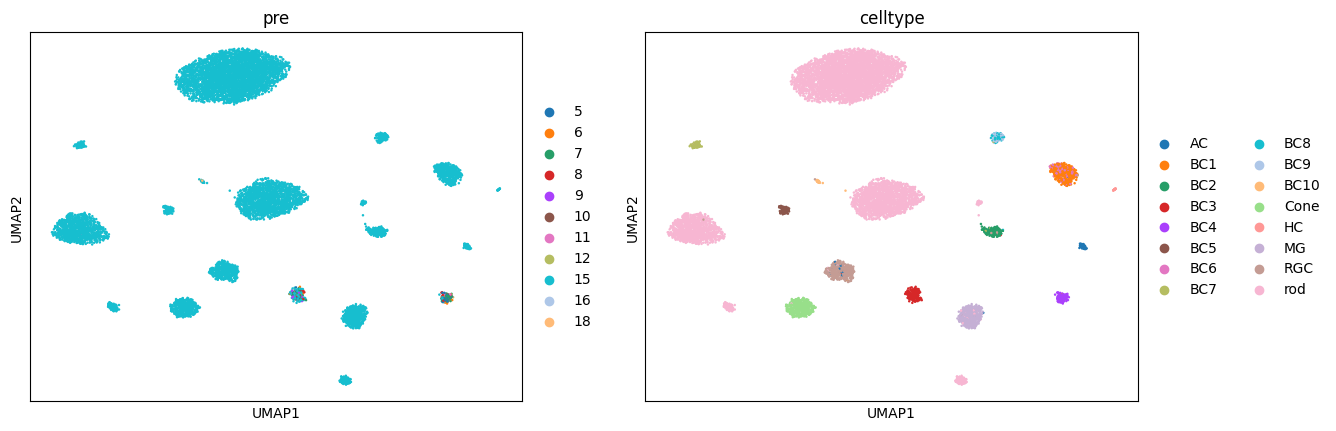

In [16]:
sc.pl.umap(adata, color=['pre', 'celltype'], show=True)

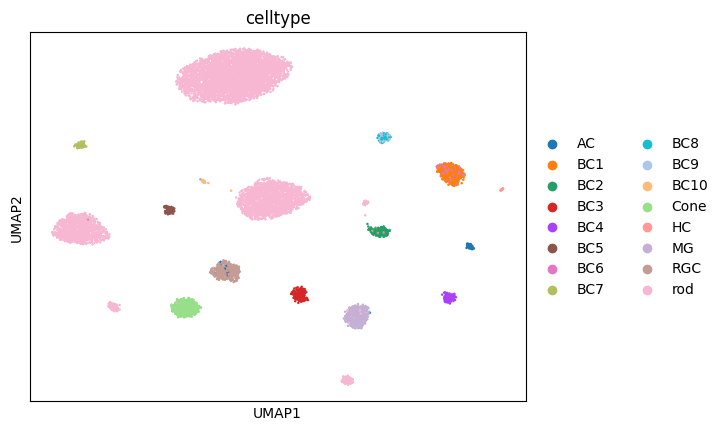

In [17]:
sc.pl.umap(adata, color=['celltype'], show=True)